# Value Sanity Checking

Goal: Only check whether the dataset contains problematic values; do not modify any values or remove any users.

Checks:
- Missing values (missing)
- Infinite values (inf / -inf)
- Semantic range violations:
  - Specified proportion columns should be within [0, 1]
  - Non-negative columns should not contain negative values
- Constant columns (all values identical)
- IQR outlier ratio (used as a warning only; do not mark as FAIL based on this alone)

Test results:
- Show each check as PASS / FAIL / WARN
- Output only the check conclusions; do not output the cleaned CSV

In [17]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

# --------------------
# Config
# --------------------
hist_rows = 6
hist_cols = 5
hist_bins = 30

# Resolve input path from either project root or data_cleaning folder
candidate_input_paths = [
    Path('out/features.csv'),
    Path('../out/features.csv')
]
input_csv_path = next((p for p in candidate_input_paths if p.exists()), None)
if input_csv_path is None:
    tried_paths = ', '.join(str(p) for p in candidate_input_paths)
    raise FileNotFoundError(f'Cannot find features.csv. Tried: {tried_paths}')

df_raw = pd.read_csv(input_csv_path)
print(f'Input CSV path: {input_csv_path.resolve()}')
print(f'Dataset shape: {df_raw.shape}')

Input CSV path: /home/dicksonyu1230/exchange/MLBD/CS_421_MLBD/out/features.csv
Dataset shape: (799, 29)


In [18]:
id_col = 'user_id' if 'user_id' in df_raw.columns else None
if id_col is None:
    id_col = 'row_id'
    df_raw = df_raw.reset_index().rename(columns={'index': id_col})

numeric_cols = df_raw.select_dtypes(include='number').columns.tolist()
feature_cols = [c for c in numeric_cols if c != id_col]

# Explicit semantic groups for this feature set
bounded_0_1_candidates = [
    'avg_video_completion_ratio',
    'video_completion_rate',
    'avg_scroll_depth_ratio',
    'p90_scroll_depth_ratio',
    'quiz_accuracy',
    'quiz_score_ratio',
    'hint_dependency_index',
    'hint_to_accuracy_ratio',
    'average_score_ratio',
    'error_recovery_rate'
]
bounded_0_1_cols = [c for c in bounded_0_1_candidates if c in feature_cols]

signed_allowed_candidates = ['performance_trend_slope', 'engagement_trend', 'score_trend']
signed_allowed_cols = [c for c in signed_allowed_candidates if c in feature_cols]
non_negative_cols = [c for c in feature_cols if c not in signed_allowed_cols]

print(f'ID column: {id_col}')
print(f'Numeric feature count: {len(feature_cols)}')
print(f'Bounded [0,1] feature count: {len(bounded_0_1_cols)}')
print(f'Non-negative feature count: {len(non_negative_cols)}')

display(df_raw[[id_col] + feature_cols[:8]].head())

ID column: user_id
Numeric feature count: 28
Bounded [0,1] feature count: 10
Non-negative feature count: 25


,user_id,active_days,login_events,login_gap_days_mean,login_gap_days_var,total_active_learning_time_seconds,avg_video_completion_ratio,video_completion_rate,videos_interacted
0,127,52.0,1182.0,0.161014,2.216906,1284755.251,0.883539,0.861111,36.0
1,525,49.0,340.0,0.557687,9.295104,2882417.563,0.396274,0.000000,15.0
2,564,9.0,194.0,0.553797,22.164923,757592.424,0.263563,0.000000,3.0
3,568,49.0,665.0,0.277277,2.380759,1747498.850,0.660332,0.333333,6.0
4,569,49.0,957.0,0.190263,1.895040,2069719.087,0.514432,0.428571,7.0


In [19]:
# Detailed sanity checks

missing_per_feature = df_raw[feature_cols].isna().sum().sort_values(ascending=False)
missing_cells_total = int(missing_per_feature.sum())

inf_counts = np.isinf(df_raw[feature_cols].to_numpy(dtype=float)).sum(axis=0)
inf_per_feature = pd.Series(inf_counts, index=feature_cols).sort_values(ascending=False)
inf_cells_total = int(inf_per_feature.sum())

bounded_violations = pd.Series(dtype='int64')
if bounded_0_1_cols:
    bounded_violations = pd.Series({
        col: int(((df_raw[col] < 0) | (df_raw[col] > 1)).sum())
        for col in bounded_0_1_cols
    }).sort_values(ascending=False)
bounded_violation_total = int(bounded_violations.sum()) if len(bounded_violations) else 0

negative_violations = pd.Series({
    col: int((df_raw[col] < 0).sum())
    for col in non_negative_cols
}).sort_values(ascending=False)
negative_violations = negative_violations[negative_violations > 0]
negative_violation_total = int(negative_violations.sum()) if len(negative_violations) else 0

constant_features = df_raw[feature_cols].nunique(dropna=False)
constant_features = constant_features[constant_features <= 1].sort_values()

# IQR outlier ratio as warning-only signal
outlier_ratio = {}
for col in feature_cols:
    q1 = df_raw[col].quantile(0.25)
    q3 = df_raw[col].quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        outlier_ratio[col] = 0.0
        continue
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_ratio[col] = float(((df_raw[col] < lower) | (df_raw[col] > upper)).mean())
outlier_ratio = pd.Series(outlier_ratio).sort_values(ascending=False)

print(f'Total missing cells: {missing_cells_total}')
print(f'Total infinite cells: {inf_cells_total}')
print(f'Total [0,1] range violations: {bounded_violation_total}')
print(f'Total negative violations (non-negative features): {negative_violation_total}')
print(f'Constant features count: {len(constant_features)}')

print('\nTop [0,1] range violations:')
display(bounded_violations[bounded_violations > 0].head(20))

print('\nTop negative violations:')
display(negative_violations.head(20))

print('\nTop IQR outlier-ratio features (warning only):')
display(outlier_ratio.head(15))

Total missing cells: 0
Total infinite cells: 0
Total [0,1] range violations: 0
Total negative violations (non-negative features): 0
Constant features count: 0

Top [0,1] range violations:


Series([], dtype: int64)


Top negative violations:


Series([], dtype: int64)


Top IQR outlier-ratio features (warning only):


engagement_trend                      0.125156
chatbot_prompt_effort_chars           0.110138
score_trend                           0.097622
performance_trend_slope               0.097622
login_gap_days_var                    0.096370
pause_events                          0.082603
replay_events                         0.076345
total_active_learning_time_seconds    0.073842
p90_scroll_depth_ratio                0.068836
score_variance                        0.063830
pause_per_video                       0.062578
videos_interacted                     0.052566
chatbot_session_depth                 0.047559
avg_video_completion_ratio            0.045056
login_gap_days_mean                   0.041302
dtype: float64

In [20]:
# PASS / FAIL / WARN test summary

test_rows = [
    {
        'test_name': 'Missing values check',
        'status': 'PASS' if missing_cells_total == 0 else 'FAIL',
        'detail': f'missing_cells_total={missing_cells_total}'
    },
    {
        'test_name': 'Infinite values check',
        'status': 'PASS' if inf_cells_total == 0 else 'FAIL',
        'detail': f'inf_cells_total={inf_cells_total}'
    },
    {
        'test_name': '[0,1] range check',
        'status': 'PASS' if bounded_violation_total == 0 else 'FAIL',
        'detail': f'bounded_violation_total={bounded_violation_total}'
    },
    {
        'test_name': 'Non-negative check',
        'status': 'PASS' if negative_violation_total == 0 else 'FAIL',
        'detail': f'negative_violation_total={negative_violation_total}'
    },
    {
        'test_name': 'Constant-feature check',
        'status': 'PASS' if len(constant_features) == 0 else 'WARN',
        'detail': f'constant_features={len(constant_features)}'
    },
    {
        'test_name': 'IQR outlier-ratio check',
        'status': 'WARN' if (outlier_ratio > 0.10).any() else 'PASS',
        'detail': f'features_with_outlier_ratio_gt_10pct={int((outlier_ratio > 0.10).sum())}'
    }
]

test_report = pd.DataFrame(test_rows)
overall_status = 'PASS' if (test_report['status'] == 'FAIL').sum() == 0 else 'FAIL'

print('=== Test Report ===')
display(test_report)
print(f'Overall result: {overall_status}')

if len(constant_features) > 0:
    print('\nConstant features (WARN):')
    display(constant_features)

if (outlier_ratio > 0.10).any():
    print('\nFeatures with IQR outlier ratio > 10% (WARN):')
    display(outlier_ratio[outlier_ratio > 0.10])

=== Test Report ===


,test_name,status,detail
0,Missing values check,PASS,missing_cells_total=0
1,Infinite values check,PASS,inf_cells_total=0
2,"[0,1] range check",PASS,bounded_violation_total=0
3,Non-negative check,PASS,negative_violation_total=0
4,Constant-feature check,PASS,constant_features=0
5,IQR outlier-ratio check,WARN,features_with_outlier_ratio_gt_10pct=2


Overall result: PASS

Features with IQR outlier ratio > 10% (WARN):


engagement_trend               0.125156
chatbot_prompt_effort_chars    0.110138
dtype: float64

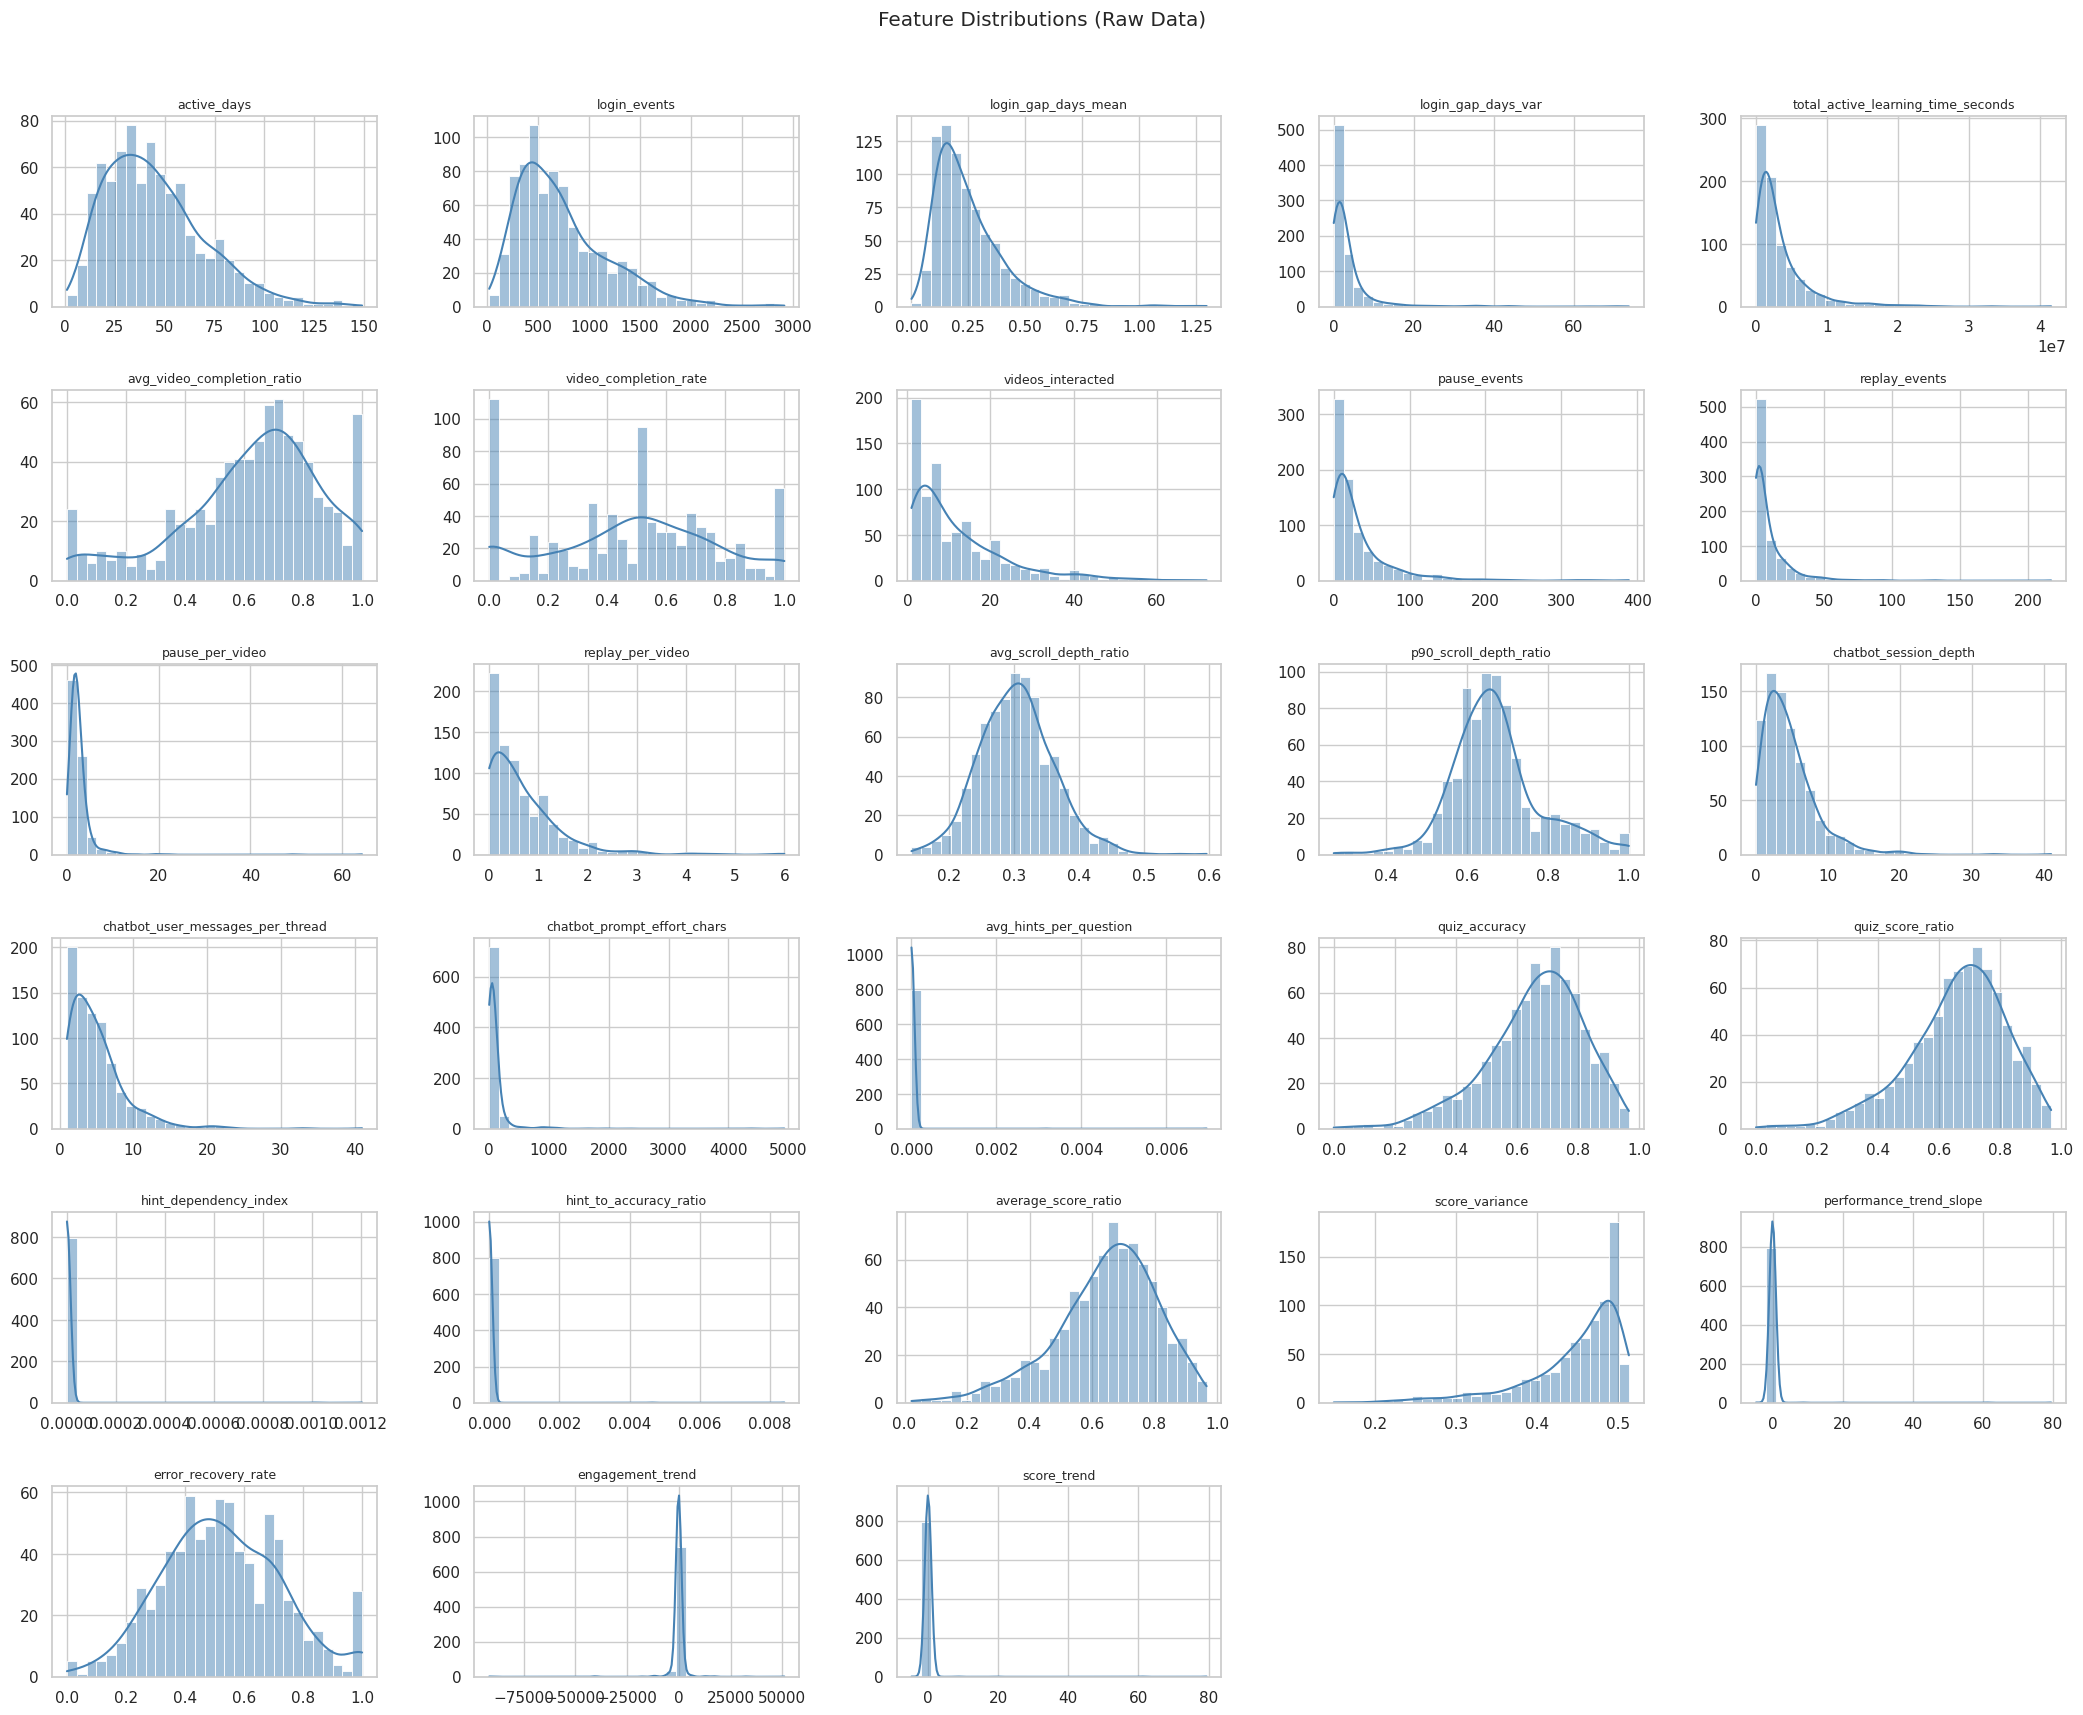

In [21]:
# Histogram view for all numeric features (6 x 5 layout)

max_plots = hist_rows * hist_cols
plot_features = feature_cols[:max_plots]

if len(feature_cols) > max_plots:
    print(f'Feature count {len(feature_cols)} exceeds {max_plots}; showing first {max_plots} features only.')

fig, axes = plt.subplots(hist_rows, hist_cols, figsize=(hist_cols * 4.2, hist_rows * 2.8))
axes = axes.flatten()

for i, feature in enumerate(plot_features):
    sns.histplot(df_raw[feature].dropna(), bins=hist_bins, kde=True, color='steelblue', ax=axes[i])
    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(plot_features), max_plots):
    axes[j].axis('off')

plt.suptitle('Feature Distributions (Raw Data)', y=1.02)
plt.tight_layout()
plt.show()